In [17]:
import yfinance as yf
import pandas as pd

In [ ]:
from model import DataFetcher
# DataFetcher class to retrieve stock data
# This class takes a stock ticker, start date, and end date as input and uses the yfinance library to fetch historical stock data.
# The fetch_data method downloads the data and returns it as a DataFrame.
# Example usage:
# data_fetcher = DataFetcher('AAPL', '2020-01-01', '2021-01-01')

In [19]:
# Get user input for stock ticker and date range
ticker = input("Enter the stock ticker (e.g., AAPL): ")
start_date = input("Enter the start date (YYYY-MM-DD): ")
end_date = input("Enter the end date (YYYY-MM-DD): ")
stock_data = DataFetcher(ticker, start_date, end_date).fetch_data()
print(stock_data.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker            ^NSEI        ^NSEI        ^NSEI        ^NSEI  ^NSEI
Date                                                                 
2007-09-17  4494.649902  4549.049805  4482.850098  4518.450195      0
2007-09-18  4546.200195  4551.799805  4481.549805  4494.100098      0
2007-09-19  4732.350098  4739.000000  4550.250000  4550.250000      0
2007-09-20  4747.549805  4760.850098  4721.149902  4734.850098      0
2007-09-21  4837.549805  4855.700195  4733.700195  4752.950195      0


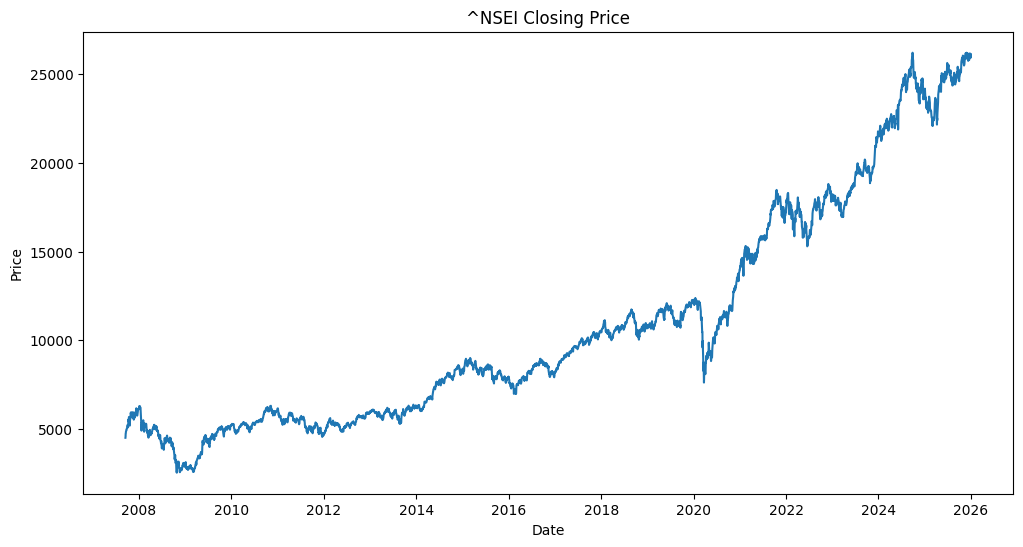

In [20]:
# Visualize the closing price
# This code uses the matplotlib library to create a line plot of the closing price of the stock over time. The x-axis represents the date, and the y-axis represents the closing price. The plot is displayed using plt.show().
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Close'])
plt.title(f'{ticker} Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

import numpy as np

In [22]:
# Set device for PyTorch
# This code checks if a GPU is available and sets the device accordingly. If a GPU is available, it will use 'cuda'; otherwise, it will fall back to 'cpu'. This allows the code to take advantage of GPU acceleration if possible.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [23]:
# Preprocess the data
# This code uses the StandardScaler from scikit-learn to normalize the closing price data. Normalization is a common preprocessing step in machine learning that helps improve the performance of models by scaling the features to a standard range. The fit_transform method is used to fit the scaler to the data and then transform it in one step.
# Note: In a real implementation, you would typically want to fit the scaler on the training data and then transform both the training and test data separately to avoid data leakage. Here, for simplicity, we are applying it directly to the entire dataset.
scaler = StandardScaler()
stock_data['Close'] = scaler.fit_transform(stock_data['Close'])

# Create sequences for LSTM
# This code creates sequences of closing price data to be used as input for an LSTM model. The seq_length variable defines the length of each sequence (in this case, 60 time steps). The loop iterates through the stock data and appends sequences of closing prices to the data list. Each sequence consists of seq_length closing prices followed by the next closing price, which will be used as the target for prediction.

seq_length = 60
data = []

# Loop through the stock data and create sequences of closing prices

for i in range(len(stock_data) - seq_length):
    data.append(stock_data['Close'].values[i:i+seq_length])

# Convert the list of sequences to a NumPy array for easier manipulation and to be compatible with PyTorch tensors.

data = np.array(data)

In [24]:
# Split the data into training and testing sets
# This code splits the data into training and testing sets. The train_size variable is calculated as 80% of the total data length. The data is then sliced to create X_train, y_train, X_test, and y_test tensors. The input features (X) consist of the sequences of closing prices, while the target labels (y) consist of the next closing price following each sequence. The tensors are converted to float and moved to the specified device (CPU or GPU) for training the model.

train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).float().to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).float().to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).float().to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).float().to(device)

In [ ]:
from model import PredictionModel
model = PredictionModel(input_size=1, hidden_size=50, num_layers=2, output_size=1).to(device)

In [ ]:
# Define the loss function and optimizer
# This code defines the loss function and optimizer for training the model. The Mean Squared Error (MSE) loss function is used to measure the difference between the predicted closing prices and the actual closing prices. The Adam optimizer is used to update the model's parameters during training, with a learning rate of 0.01. The optimizer takes the model's parameters as input, which allows it to compute the gradients and update the weights accordingly during backpropagation.
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [28]:
num_epochs = 20000

# Train the model
# This code trains the model for a specified number of epochs. In each epoch, the model makes predictions on the training data, calculates the loss using the defined criterion, and then performs backpropagation to update the model's parameters using the optimizer. The loss is printed every 25 epochs to monitor the training progress.

for i in range(num_epochs):
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)
    
    if i % 25 == 0:
        print(f'Epoch {i}/{num_epochs}, Loss: {loss.item()}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch 0/20000, Loss: 0.5890166759490967
Epoch 25/20000, Loss: 0.03000296652317047
Epoch 50/20000, Loss: 0.002022446133196354
Epoch 75/20000, Loss: 0.0009584497311152518
Epoch 100/20000, Loss: 0.0007213351200334728
Epoch 125/20000, Loss: 0.0006432300433516502
Epoch 150/20000, Loss: 0.0006093149422667921
Epoch 175/20000, Loss: 0.000587417627684772
Epoch 200/20000, Loss: 0.0005690256948582828
Epoch 225/20000, Loss: 0.0005524079315364361
Epoch 250/20000, Loss: 0.0005371052538976073
Epoch 275/20000, Loss: 0.0005231927498243749
Epoch 300/20000, Loss: 0.000510398531332612
Epoch 325/20000, Loss: 0.0004986791755072773
Epoch 350/20000, Loss: 0.00048790135770104825
Epoch 375/20000, Loss: 0.000477926863823086
Epoch 400/20000, Loss: 0.00046865170588716865
Epoch 425/20000, Loss: 0.00045998796122148633
Epoch 450/20000, Loss: 0.0004519685753621161
Epoch 475/20000, Loss: 0.00044421039638109505
Epoch 500/20000, Loss: 0.00043686284334398806
Epoch 525/20000, Loss: 0.0004296978295315057
Epoch 550/20000, Lo

In [29]:
# Evaluate the model
# This code evaluates the trained model on the test data. The model is set to evaluation mode using model.eval(), which disables dropout and batch normalization layers (if present) and allows the model to make predictions without updating its parameters. The model makes predictions on the test data, and then both the predicted and actual values are inverse transformed using the scaler to return them to their original scale. This allows for a more meaningful comparison between the predicted and actual closing prices.
# The predicted and actual values are then stored in y_test_pred and y_test, respectively, for further analysis or visualization.

model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.cpu().detach().numpy())
y_train = scaler.inverse_transform(y_train.cpu().detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.cpu().detach().numpy())
y_test = scaler.inverse_transform(y_test.cpu().detach().numpy())



In [32]:
# Calculate and print the Root Mean Squared Error (RMSE) for both the training and testing sets. The RMSE is a common metric used to evaluate the performance of regression models, and it provides a measure of how well the model's predictions match the actual values. A lower RMSE indicates better performance, with an RMSE of 0 indicating perfect predictions.
# The root_mean_squared_error function from scikit-learn is used to calculate the RMSE by comparing the predicted values (y_train_pred and y_test_pred) with the actual values (y_train and y_test) for both the training and testing sets. The results are printed to the console for review.

train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

print(f'Train RMSE: {train_rmse}')
print(f'Test RMSE: {test_rmse}')

Train RMSE: 20.080860137939453
Test RMSE: 2378.106689453125


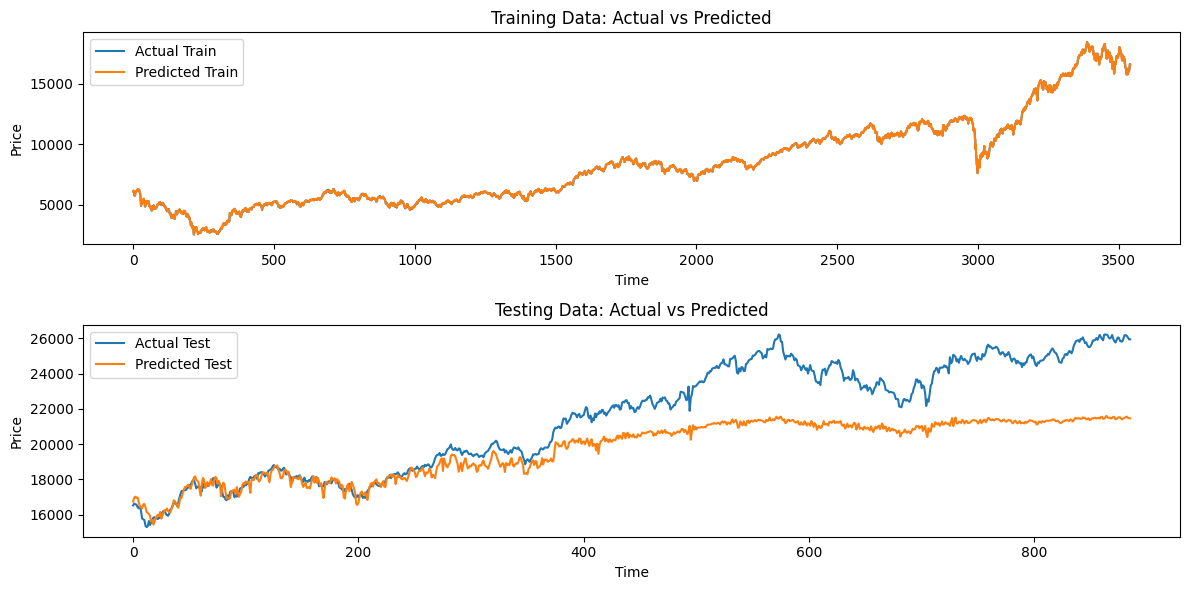

In [33]:
# Visualize the results
# This code creates a figure with two subplots to visualize the actual vs predicted closing prices for both the training and testing data. The first subplot shows the actual and predicted values for the training data, while the second subplot shows the same for the testing data. Each plot includes a title, axis labels, and a legend to differentiate between actual and predicted values. The plt.tight_layout() function is used to adjust the spacing between subplots for better visualization, and plt.show() is called to display the figure.

final_fig = plt.figure(figsize=(12, 6))
gs = final_fig.add_gridspec(2, 1)
ax1 = final_fig.add_subplot(gs[0, 0])
ax1.plot(y_train, label='Actual Train')
ax1.plot(y_train_pred, label='Predicted Train')
ax1.set_title('Training Data: Actual vs Predicted')
ax1.set_xlabel('Time')
ax1.set_ylabel('Price')
ax1.legend()
ax2 = final_fig.add_subplot(gs[1, 0])
ax2.plot(y_test, label='Actual Test')
ax2.plot(y_test_pred, label='Predicted Test')
ax2.set_title('Testing Data: Actual vs Predicted')
ax2.set_xlabel('Time')
ax2.set_ylabel('Price')
ax2.legend()
plt.tight_layout()
plt.show()